## Multimodal approaches

In [1]:
import pandas as pd
import numpy as np
import torch
import timm
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizer, DistilBertModel
import xgboost as xgb
from tqdm import tqdm
import cv2
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
IMG_SIZE = 224
MODEL_PATH = "../data/best_vision_model.pth"

# Data preprocessing

train_df = pd.read_csv('../data/train_cleaned.csv')
test_df = pd.read_csv('../data/test_cleaned.csv')

le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_test = le.transform(test_df['label'])

print(f"Labels: {le.classes_}")

c:\Users\chess\miniconda3\envs\multimodal_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Labels: ['drink' 'food' 'inside' 'menu' 'outside']


In [10]:
# Generating visual features
class InferenceDataset(Dataset):
    def __init__(self, df, root_dirs):
        self.df = df
        self.root_dirs = root_dirs
        self.transform = A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        
        for root in self.root_dirs:
            path = os.path.join(root, f"{row['photo_id']}.jpg")
            if os.path.exists(path):
                img_read = cv2.imread(path)
                if img_read is not None:
                    image = cv2.cvtColor(img_read, cv2.COLOR_BGR2RGB)
                    break
                else:
                    print("Warning: Image not found", row['photo_id'])
        
        aug = self.transform(image=image)
        return aug['image']

def get_cnn_predictions(df, model_path):
    model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=len(le.classes_))
    model.load_state_dict(torch.load(model_path))
    model.to(DEVICE)
    model.eval()

    dataset = InferenceDataset(df, root_dirs=['../data/train', '../data/test'])
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    all_probs = []
    with torch.no_grad():
        for images in tqdm(loader, desc="CNN Inference"):
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            
    return np.vstack(all_probs)

X_img_train = get_cnn_predictions(train_df, MODEL_PATH)
X_img_test = get_cnn_predictions(test_df, MODEL_PATH)

print(f"CNN Features shape: {X_img_train.shape}")

CNN Inference: 100%|██████████| 139/139 [00:17<00:00,  8.06it/s]

CNN Features shape: (30286, 5)


In [4]:
# Logistic regression text features
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_text_raw_train = vectorizer.fit_transform(train_df['caption'].fillna(''))
X_text_raw_test = vectorizer.transform(test_df['caption'].fillna(''))

lr = LogisticRegression(max_iter=1000, n_jobs=-1)
lr.fit(X_text_raw_train, y_train)

# Take probabilities as features
X_text_lr_train = lr.predict_proba(X_text_raw_train)
X_text_lr_test = lr.predict_proba(X_text_raw_test)
print(f"LogReg Features shape: {X_text_lr_train.shape}")

LogReg Features shape: (30286, 5)


In [5]:
# DistilBERT embeddings text features
def get_bert_embeddings(text_series):
    print("Retrieving embeddings from DistilBERT...")
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    model = DistilBertModel.from_pretrained('distilbert-base-uncased')
    model.to(DEVICE)
    model.eval()
    
    embeddings = []
    batch_size = 32
    texts = text_series.fillna("").tolist()
    
    for i in tqdm(range(0, len(texts), batch_size), desc="BERT Inference"):
        batch_texts = texts[i : i + batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=128)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        # last_hidden_state shape: (batch, seq_len, 768) -> taking [:, 0, :]
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embeddings)
        
    return np.vstack(embeddings)

X_text_bert_train = get_bert_embeddings(train_df['caption'])
X_text_bert_test = get_bert_embeddings(test_df['caption'])
print(f"BERT Features shape: {X_text_bert_train.shape}")

Retrieving embeddings from DistilBERT...


BERT Inference: 100%|██████████| 947/947 [00:19<00:00, 47.37it/s]


Retrieving embeddings from DistilBERT...


BERT Inference: 100%|██████████| 139/139 [00:02<00:00, 48.11it/s]

BERT Features shape: (30286, 768)


In [11]:
# Meta features generation
def get_meta_features(df):
    df['cap_len'] = df['caption'].astype(str).apply(len)
    df['word_count'] = df['caption'].astype(str).apply(lambda x: len(x.split()))
    return df[['cap_len', 'word_count']].values / 100.0

X_meta_train = get_meta_features(train_df)
X_meta_test = get_meta_features(test_df)

In [12]:
# XGBoost training
def train_xgboost(X_train_full, X_test_full, y_train, y_test, name=""):
    print(f"\nTraining XGBoost: {name}")
    print(f"Input Shape: {X_train_full.shape}")
    
    clf = xgb.XGBClassifier(
        n_estimators=200, 
        learning_rate=0.05, 
        max_depth=5, 
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        n_jobs=-1
    )
    
    clf.fit(X_train_full, y_train)
    y_pred = clf.predict(X_test_full)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"FINAL ACCURACY ({name}): {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    return clf, acc

### Testing different modes

In [13]:
# Experiment 1: CNN + LogReg + Meta
X_train_v1 = np.hstack([X_img_train, X_text_lr_train, X_meta_train])
X_test_v1 = np.hstack([X_img_test, X_text_lr_test, X_meta_test])

clf_v1, acc_v1 = train_xgboost(X_train_v1, X_test_v1, y_train, y_test, name="CNN + LogReg + Meta")

print(f"Result LogReg: {acc_v1:.4f}")


Training XGBoost: CNN + LogReg + Meta
Input Shape: (30286, 12)


c:\Users\chess\miniconda3\envs\multimodal_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:23:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


FINAL ACCURACY (CNN + LogReg + Meta): 0.9530
              precision    recall  f1-score   support

       drink       0.95      0.96      0.96       963
        food       0.97      0.97      0.97      1362
      inside       0.94      0.93      0.93      1043
        menu       0.93      0.93      0.93       116
     outside       0.95      0.94      0.95       945

    accuracy                           0.95      4429
   macro avg       0.95      0.95      0.95      4429
weighted avg       0.95      0.95      0.95      4429

Result LogReg: 0.9530


In [16]:
# Experiment 2: CNN + BERT + Meta
X_train_v2 = np.hstack([X_img_train, X_text_bert_train, X_meta_train])
X_test_v2 = np.hstack([X_img_test, X_text_bert_test, X_meta_test])

clf_v2, acc_v2 = train_xgboost(X_train_v2, X_test_v2, y_train, y_test, name="CNN + BERT + Meta")

print(f"Result BERT: {acc_v2:.4f}")


Training XGBoost: CNN + BERT + Meta
Input Shape: (30286, 775)


c:\Users\chess\miniconda3\envs\multimodal_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:49:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


FINAL ACCURACY (CNN + BERT + Meta): 0.9528
              precision    recall  f1-score   support

       drink       0.95      0.97      0.96       963
        food       0.97      0.97      0.97      1362
      inside       0.93      0.94      0.94      1043
        menu       0.94      0.91      0.93       116
     outside       0.95      0.94      0.95       945

    accuracy                           0.95      4429
   macro avg       0.95      0.95      0.95      4429
weighted avg       0.95      0.95      0.95      4429

Result BERT: 0.9528


In [14]:
# Experiment 3: CNN + Fine-Tuned BERT + Meta
X_text_ft_train = np.load("../data/bert_finetuned_train.npy")
X_text_ft_test = np.load("../data/bert_finetuned_test.npy")

X_train_v3 = np.hstack([X_img_train, X_text_ft_train, X_meta_train])
X_test_v3 = np.hstack([X_img_test, X_text_ft_test, X_meta_test])

clf_v3, acc_v3 = train_xgboost(X_train_v3, X_test_v3, y_train, y_test, name="CNN + FT-BERT + Meta")

print(f"Result Fine-tuned BERT: {acc_v3:.4f}")


Training XGBoost: CNN + FT-BERT + Meta
Input Shape: (30286, 12)


c:\Users\chess\miniconda3\envs\multimodal_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:23:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


FINAL ACCURACY (CNN + FT-BERT + Meta): 0.9562
              precision    recall  f1-score   support

       drink       0.95      0.97      0.96       963
        food       0.97      0.97      0.97      1362
      inside       0.94      0.94      0.94      1043
        menu       0.92      0.93      0.93       116
     outside       0.95      0.95      0.95       945

    accuracy                           0.96      4429
   macro avg       0.95      0.95      0.95      4429
weighted avg       0.96      0.96      0.96      4429

Result Fine-tuned BERT: 0.9562


## Comparing Cascade to CNN


Error analysis: where cascade wins

Total test samples: 4429
CNN mistakes: 221
Corrected by ensemble: 57


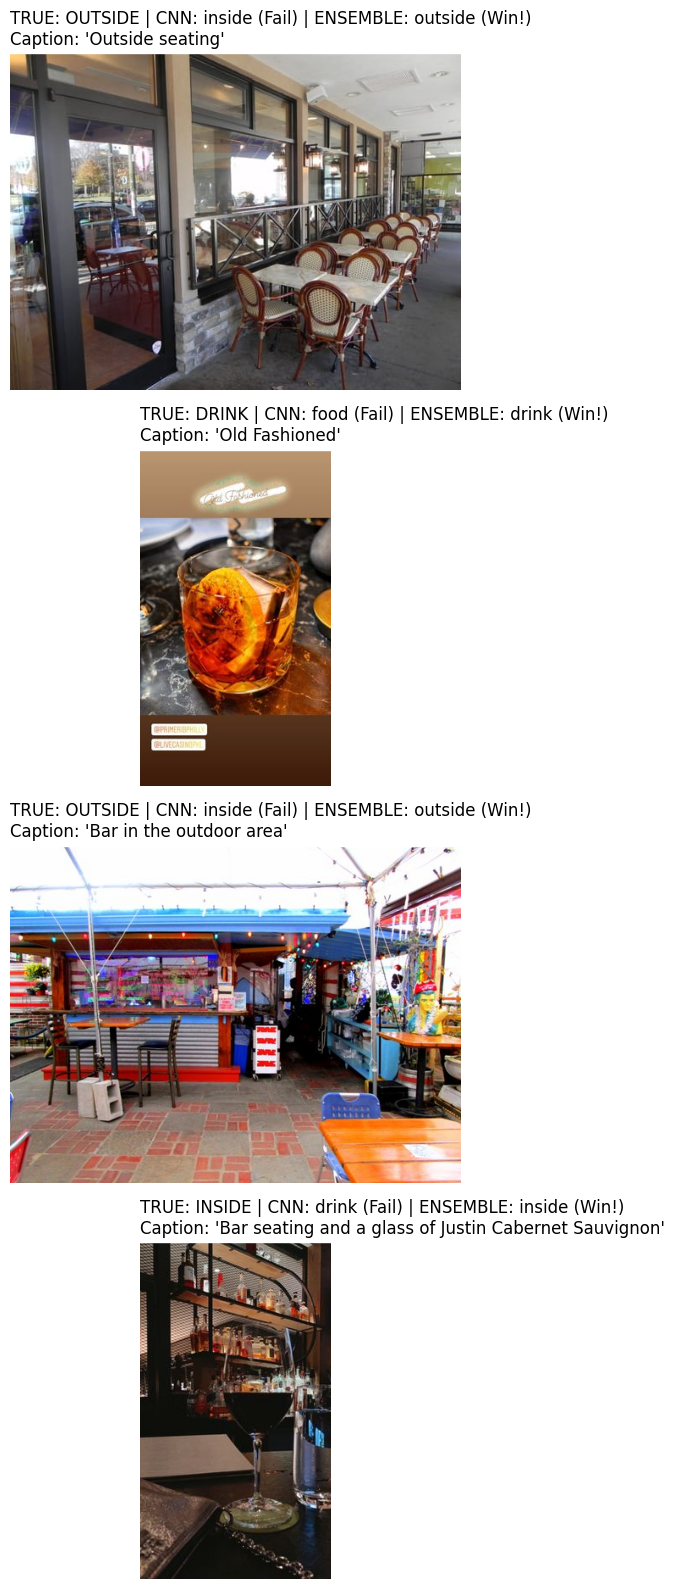

In [22]:
import matplotlib.pyplot as plt
import cv2

def show_ensemble_wins(X_img_test, X_final_test, y_test, df_test, clf, le, num_samples=5):
    print("\nError analysis: where cascade wins\n")

    y_pred_cnn = np.argmax(X_img_test, axis=1)
    y_pred_ensemble = clf.predict(X_final_test)
    
    cnn_wrong = (y_pred_cnn != y_test)
    ens_right = (y_pred_ensemble == y_test)
    
    win_indices = np.where(cnn_wrong & ens_right)[0]
    
    print(f"Total test samples: {len(y_test)}")
    print(f"CNN mistakes: {np.sum(cnn_wrong)}")
    print(f"Corrected by ensemble: {len(win_indices)}")
    
    if len(win_indices) == 0:
        print("No corrected samples found in test set.")
        return

    rng = np.random.default_rng(seed=99)
    samples_idx = rng.choice(
        win_indices,
        min(len(win_indices), num_samples),
        replace=False
    )[1:]
    
    plt.figure(figsize=(15, 4 * len(samples_idx)))
    
    for i, idx in enumerate(samples_idx):
        row = df_test.iloc[idx]
        true_label = le.inverse_transform([y_test[idx]])[0]
        cnn_pred = le.inverse_transform([y_pred_cnn[idx]])[0]
        ens_pred = le.inverse_transform([y_pred_ensemble[idx]])[0]
        caption = row['caption'] if isinstance(row['caption'], str) else "No caption"
        
        img = np.zeros((224, 224, 3), dtype=np.uint8)
        for root in ['../data/train', '../data/test']:
            path = os.path.join(root, f"{row['photo_id']}.jpg")
            if os.path.exists(path):
                img = cv2.imread(path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                break
        
        plt.subplot(len(samples_idx), 1, i + 1)
        plt.imshow(img)
        plt.axis('off')
        
        title_text = (f"TRUE: {true_label.upper()} | "
                      f"CNN: {cnn_pred} (Fail) | "
                      f"ENSEMBLE: {ens_pred} (Win!)\n"
                      f"Caption: '{caption}'")
        
        plt.title(title_text, fontsize=12, loc='left', backgroundcolor='white')

    plt.tight_layout()
    plt.show()


show_ensemble_wins(
    X_img_test=X_img_test,
    X_final_test=X_test_v3,
    y_test=y_test,
    df_test=test_df,
    clf=clf_v3,
    le=le
)